In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import plot_settings

/tmp/ipykernel_161988/1247237079.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lim_df['solver'] = lim_df['solver'].replace({


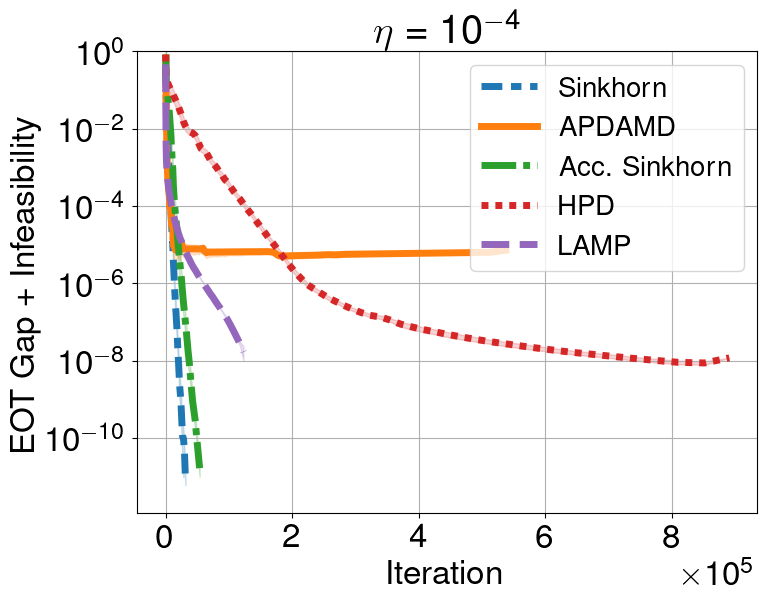

/tmp/ipykernel_161988/1247237079.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lim_df['solver'] = lim_df['solver'].replace({


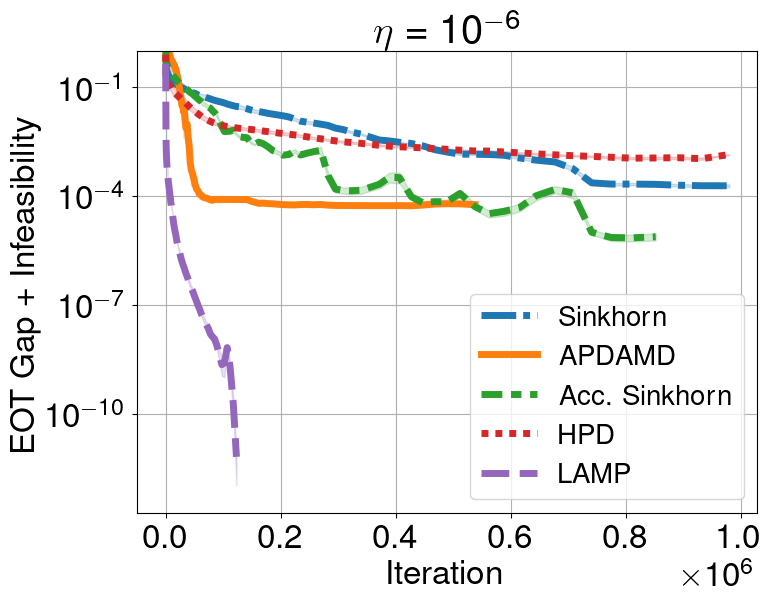

In [12]:
# probclass = 'classicimages'
import matplotlib as mpl

mpl.rcParams["font.size"] = 24
df = pd.read_csv("../data_archive/fig_1_dotmark_comp.csv")
arr = np.exp(pd.cut(np.log(df['iter']), bins=300 , precision=1,retbins=True)[0].apply(lambda x: x.mid).to_numpy())
# np.exp(arr[0].iloc[0].mid)
df['biniter'] = arr
for eta in [ 1e-4, 1e-6]:
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    lim_df = df.query(f'eta == {eta}')
    lim_df['solver'] = lim_df['solver'].replace({
        'apdamd': "APDAMD",
        'sinkhorn': "Sinkhorn",
        'lamp': "LAMP",
        'hpd': "HPD",
        'accelerated_sinkhorn': "Acc. Sinkhorn"
    })

    hue_order = [
        "Sinkhorn",
        "APDAMD",
        "Acc. Sinkhorn",
        "HPD",
        "LAMP"
    ]
    ax=sns.lineplot(lim_df, ax=ax, x='biniter', y='objective_gap', hue='solver', style="solver", hue_order=hue_order, linewidth=5)
    ax.set_yscale('log')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)

    # ax.set_xscale(10000)
    ax.set_ylim((ax.get_ylim()[0], 1))
    # ax.set_xlim((ax.get_xlim()[0], 10000))
    ax.legend(fontsize=20)
    ax.grid()
    ax.set_ylabel('EOT Gap + Infeasibility')
    ax.set_xlabel('Iteration')
    ax.set_title('$\\eta=10^{%d}$' % (round(np.log10(eta))))
    plt.show()

    fig.savefig(f'../figures/broad_dotmark_1en{eta}_lamp.pdf', bbox_inches='tight')


102491


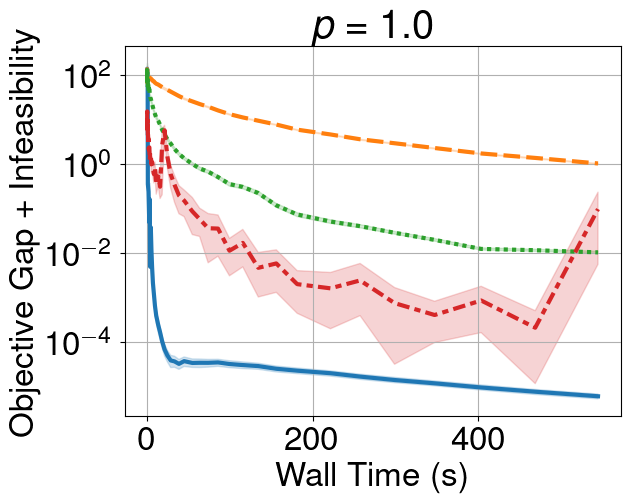

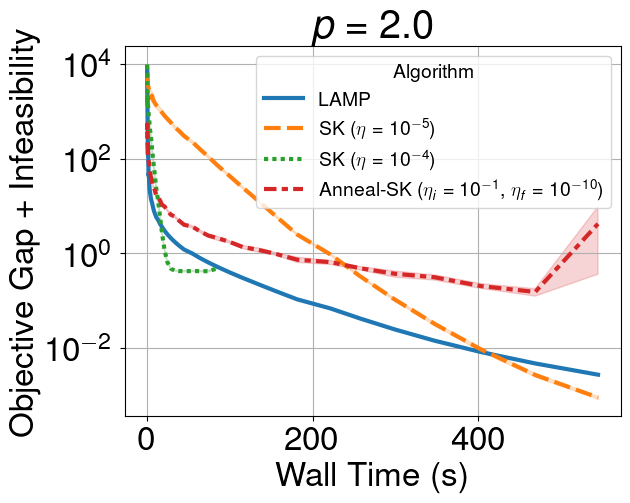

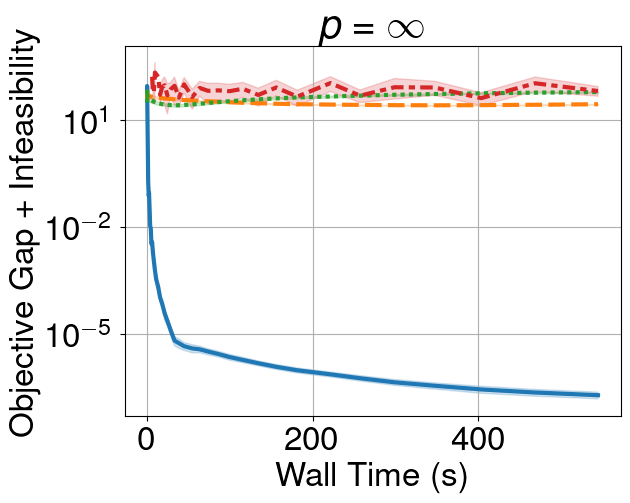

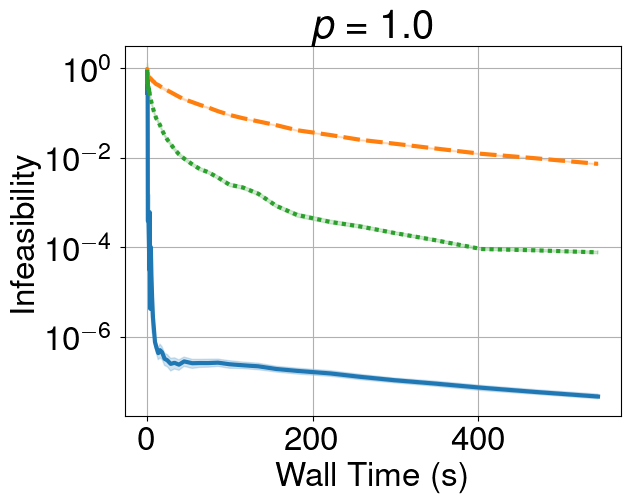

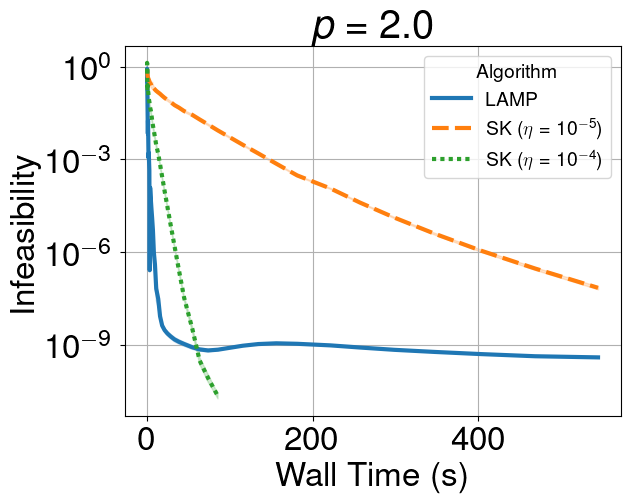

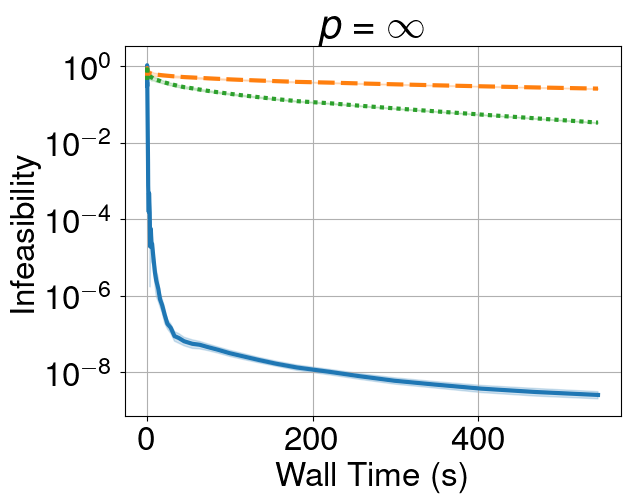

In [ ]:

df=pd.read_csv("../data_archive/fig_2_dotmark_timing.csv").drop(columns=["ot_distance"])
optimal_df = pd.read_csv("../data_archive/ground_truths_pnorms_new.csv") # exact minima found via emd2
df = df.merge(optimal_df, on=['problemclass', 'problem_1', 'problem_2', 'p'])

# minvals = df.query('infeas < 1e-3').groupby(['problemclass', 'p', 'problem_1', 'problem_2'])['ot_objective'].transform("min")
# df['objgap'] = df['ot_objective'] - df['']
df["maxval"] = df["p"].replace(
    {2: 2 * 63**2,
     1: 2 * 63,
     np.inf: 63}
)
# dff["Algorithm"] = df['solver'].replace({"sinkhorn_kernel":"SK", "lamp_cuda_ctransfer": "LAMP"})
df['gap'] = abs(df['ot_objective'] - df['ot_distance']) + abs(df['infeas']) * df["maxval"]
# df["Algorithm"] = df['solver'].replace({"sinkhorn_kernel":"SK", "extragrad_dual_ctransfer": "LAMP"})
# df["time(s)"] = (df["time(s)"]/2).round()*2
print(len(df.query("Algorithm == \"SK ($\\eta = 10^{-5}$)\"")))
arr = np.exp(pd.cut(np.log(df['time(s)']), bins=100 , precision=1,retbins=True)[0].apply(lambda x: x.mid).to_numpy())
# np.exp(arr[0].iloc[0].mid)
df['bintime'] = arr
# df.to_csv("updated_pnorm.csv", index=False)
for p, sdf in df.groupby("p"):
    fig, ax = plt.subplots(dpi=100)
    # if p == np.inf:
        # sdf = sdf.query("Algorithm != \"LAMP\"")
    hue_order=["LAMP", "SK ($\\eta = 10^{-5}$)","SK ($\\eta = 10^{-4}$)" , "Anneal-SK ($\\eta_i = 10^{-1}$, $\\eta_f = 10^{-10}$)",]
    first = True
    # for (p1, p2, pclass), ssdf in sdf.groupby(["problem_1", "problem_2", "problemclass"]):
    ax=sns.lineplot(sdf, x='bintime', y='gap', hue='Algorithm', style='Algorithm',  palette='tab10',
                    legend=False if p != 2 or not first else True, 
                   hue_order=hue_order,  style_order=hue_order, linewidth=3)
    first = False
    ax.set_yscale('log')
    ax.grid()
    ssdf = np.sort(sdf['bintime'].unique())
    infeas_offset = sdf.query("Algorithm == \"LAMP\"")
        # xv = np.linspace(0, 600, 50)
    # yv = 
    
    if p==2:
        ax.legend(fontsize=14, title='Algorithm', title_fontsize=14)
    if p != np.inf:
        ax.set_title("$p=%s$" % (str(p)))
    else:
        ax.set_title("$p=\\infty$")
    ax.set_ylabel("Objective Gap + Infeasibility")
    ax.set_xlabel("Wall Time (s)")
    plt.show()
    fig.savefig("../figures/pnorm_test_4096_%s.pdf" % (str(p)), bbox_inches='tight')

# first = True
for p, sdf in df.groupby("p"):
    fig, ax = plt.subplots(dpi=100)
    # if p == np.inf:
        # sdf = sdf.query("Algorithm != \"LAMP\"")
    
    hue_order=["LAMP", "SK ($\\eta = 10^{-5}$)","SK ($\\eta = 10^{-4}$)" ]
    first = True
    ax=sns.lineplot(sdf, x='bintime', y='infeas', hue='Algorithm',style='Algorithm',  style_order=hue_order,  palette='tab10',
                    legend=False if p != 2 or not first else True, 
                    hue_order=["LAMP", "SK ($\\eta = 10^{-5}$)","SK ($\\eta = 10^{-4}$)" ], linewidth=3)

    
    sns.lineplot
    first = False
    ax.set_yscale('log')
    ax.grid()
    
    if p==2:
        ax.legend(fontsize=14, title='Algorithm', title_fontsize=14)
    if p != np.inf:
        ax.set_title("$p=%s$" % (str(p)))
    else:
        ax.set_title("$p=\\infty$")
    ax.set_ylabel("Infeasibility")
    ax.set_xlabel("Wall Time (s)")
    fig.savefig("../figures/pnorm_test_4096_%s_infeas.pdf" % (str(p)), bbox_inches='tight')
    plt.show()

/tmp/ipykernel_161988/2340580242.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Algorithm"].replace({"LAMP ($\\eta_p = 0$)": "LAMP"}, inplace=True)


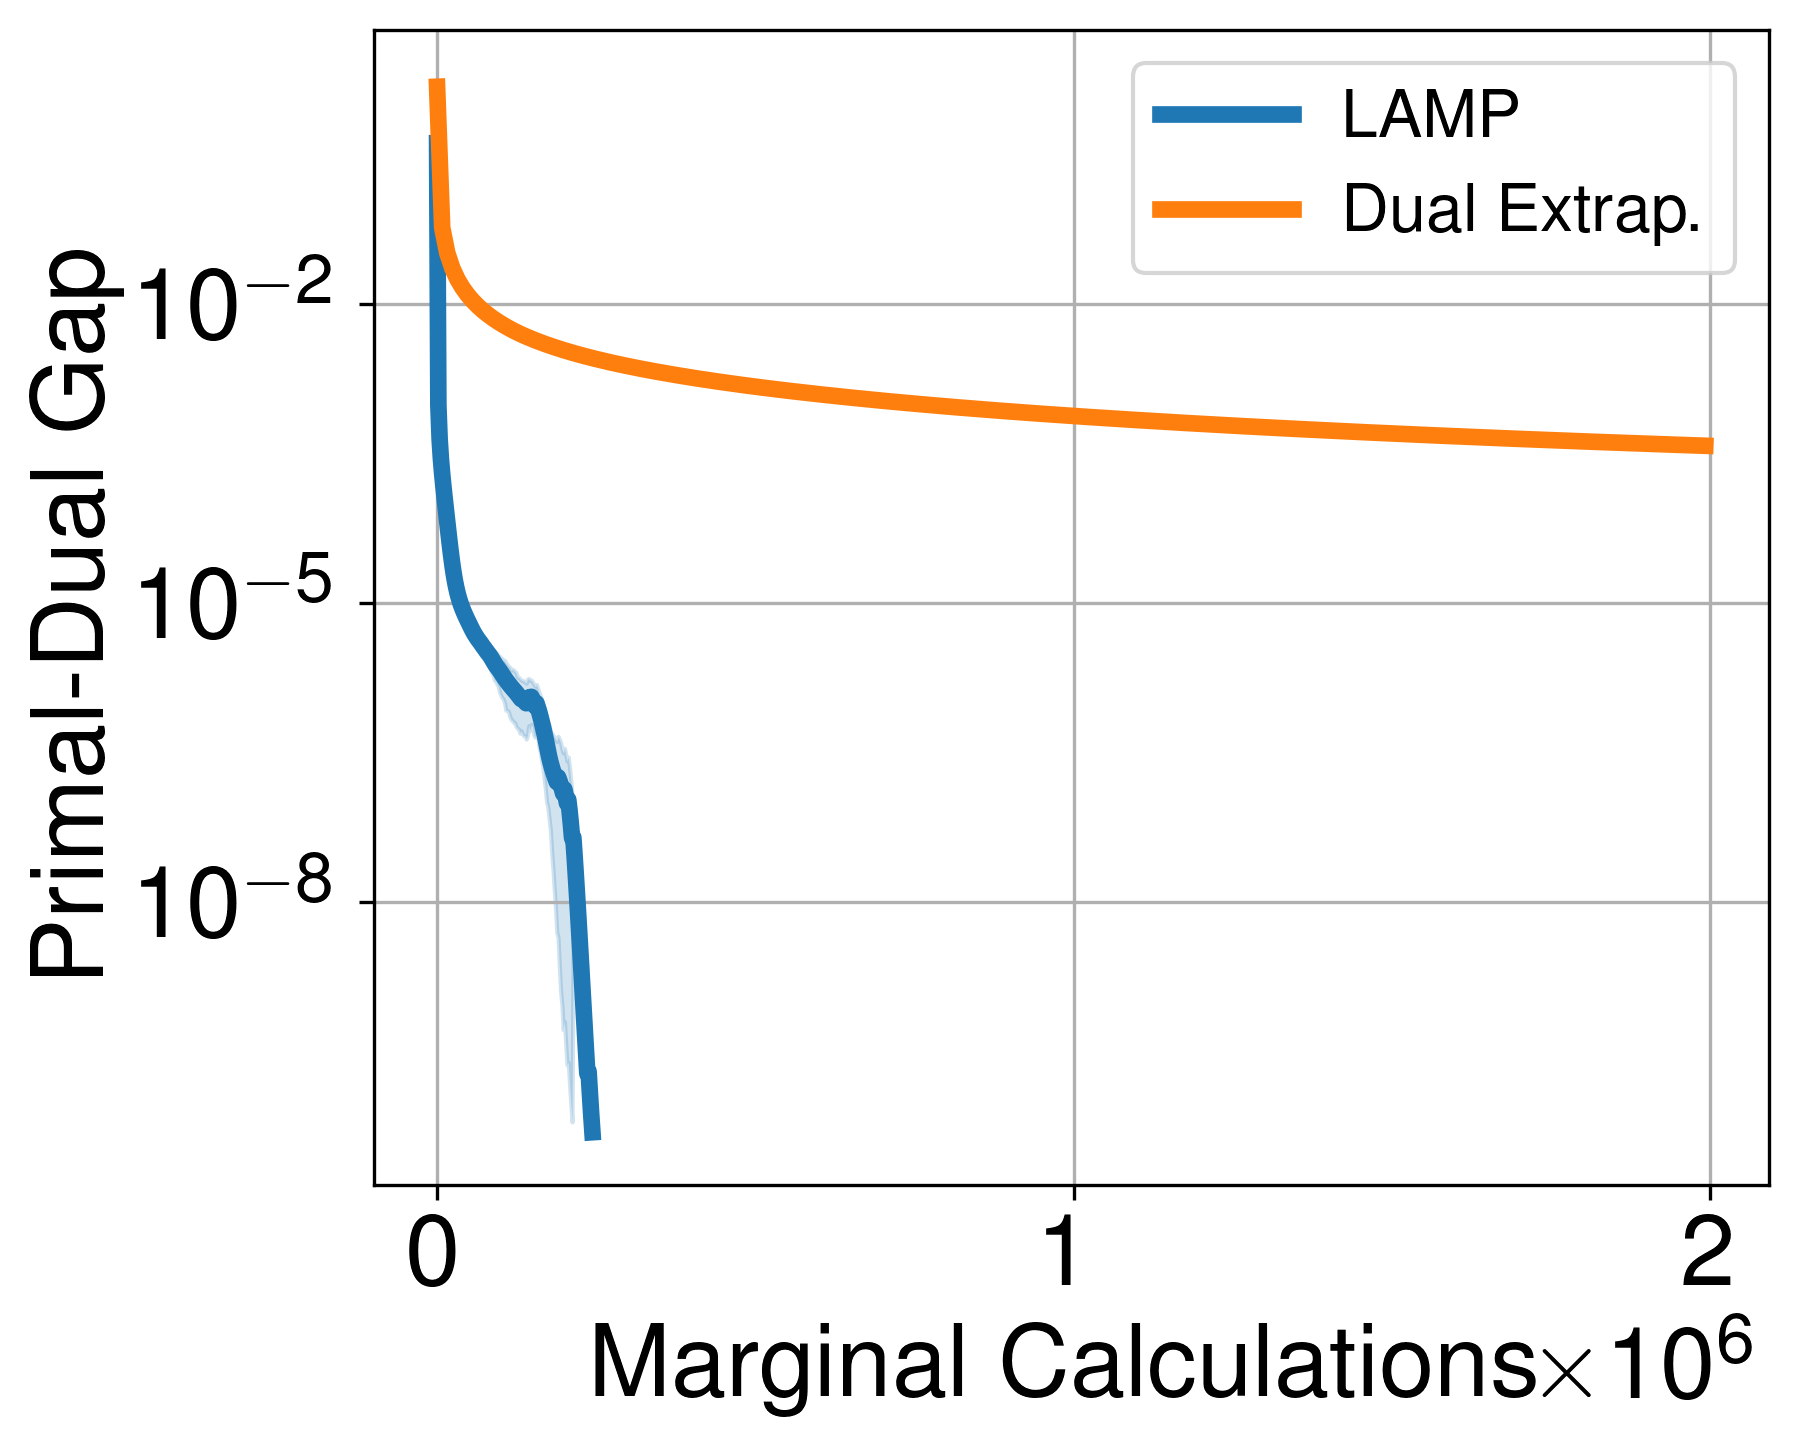

In [16]:
df = pd.read_csv("../data_archive/fig_4_dual_extrap_comp.csv")
df["Algorithm"].replace({"LAMP ($\\eta_p = 0$)": "LAMP"}, inplace=True)
fig, ax = plt.subplots(figsize=(6,5))
sns.lineplot(df.query("(iter-1) % 1000 == 0"),ax=ax, x='inner_iter', y='pdgap', hue='Algorithm', hue_order=["LAMP", "Dual Extrap."], linewidth=4)
ax.set_yscale('log')
ax.set_ylabel("Primal-Dual Gap")
ax.set_xlabel("Marginal Calculations")
ax.legend(fontsize=16)
ax.grid()
fig.savefig("../figures/dextrap_comparison.pdf", bbox_inches="tight")

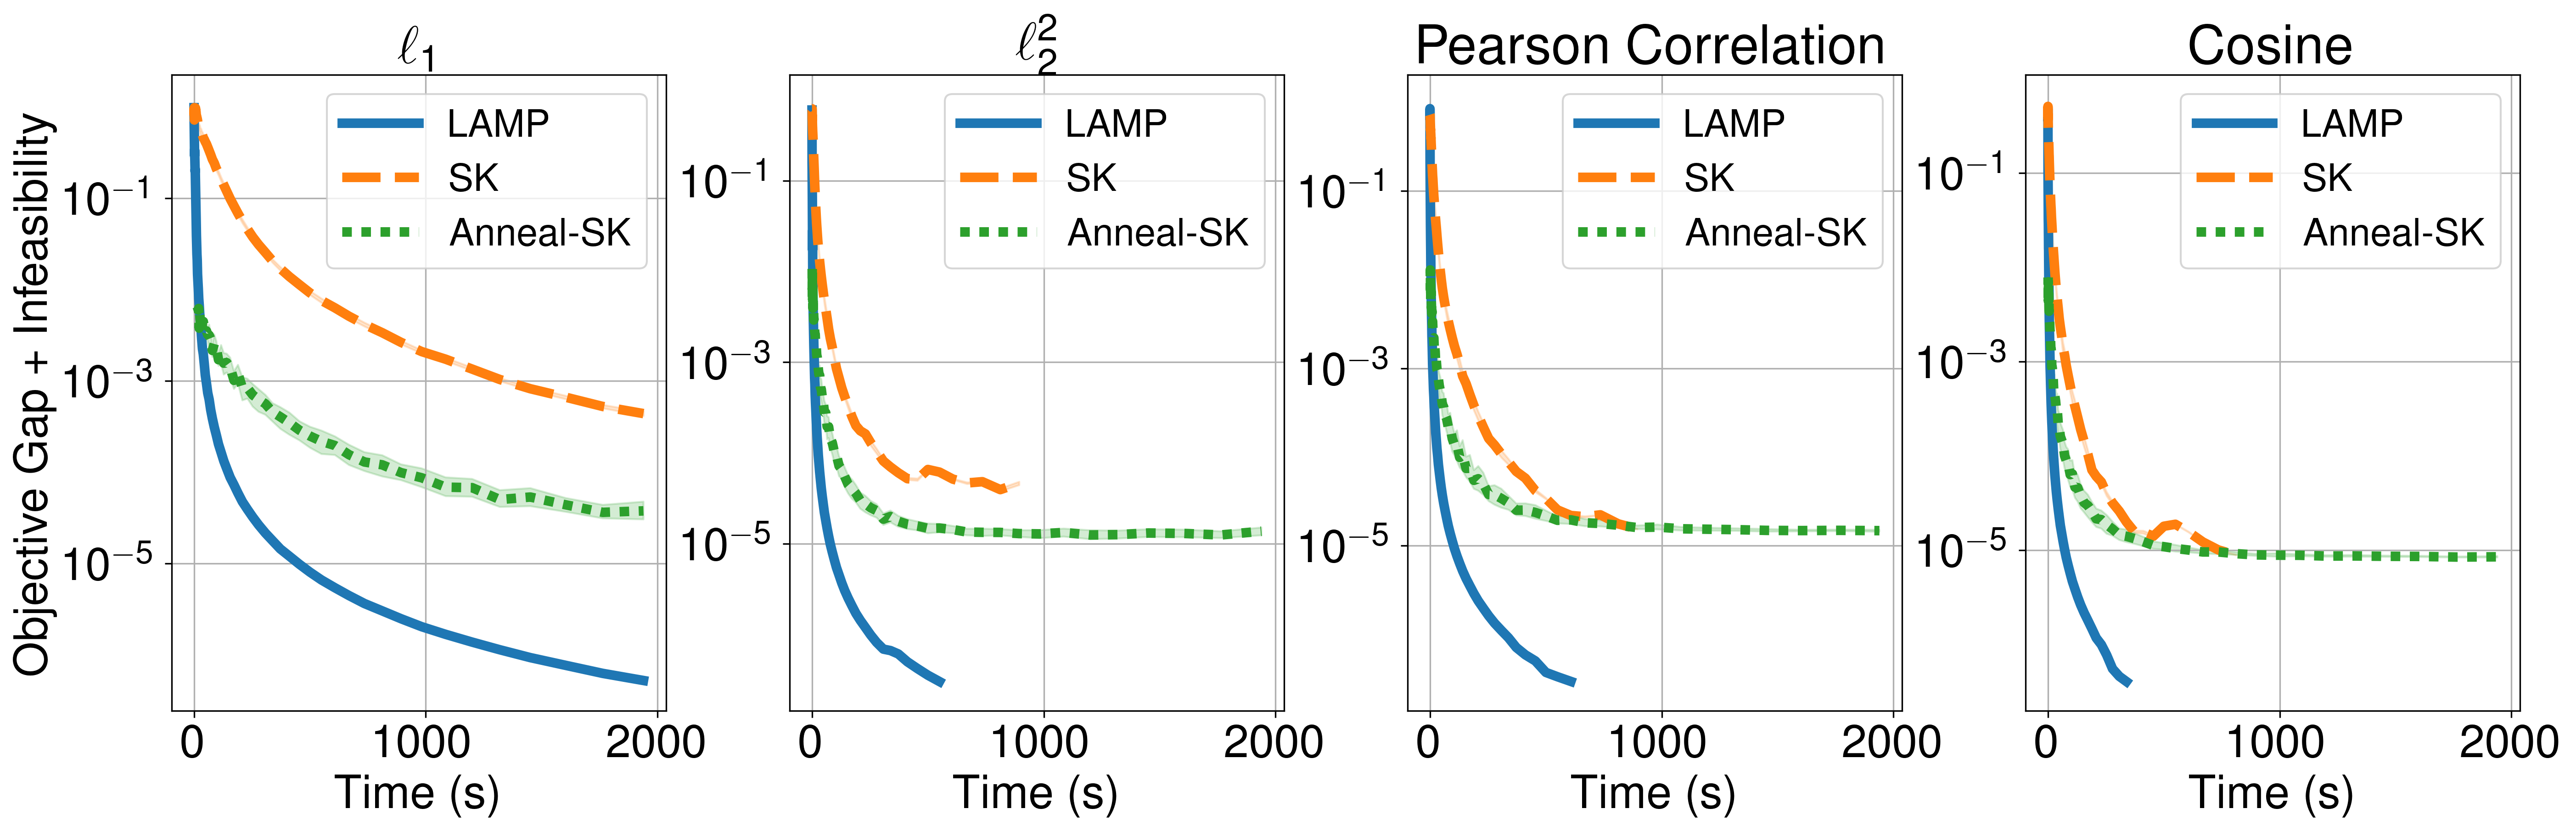

In [ ]:
import matplotlib as mpl
df = pd.read_csv("../data_archive/fig_3_cellsim.csv")
fig, axs = plt.subplot_mosaic([["$\\ell_1$", "$\\ell_2^2$","Pearson Correlation", "Cosine"]], figsize=(22,6), gridspec_kw={"wspace": 0.25})
hue_order = ["LAMP", "SK", "Anneal-SK"]
first = True
mpl.rcParams['font.size']= 24
mpl.rcParams["figure.dpi"] = 300
# plt.rc('pdf',fonttype = 1)
# mpl.rcParams['text.usetex'] = True #Let TeX do the typsetting
# mpl.rcParams['text.latex.preamble'] = '\\usepackage{sansmath}\n\\sansmath' #Force sans-serif math mode (for axes labels)
# mpl.rcParams['font.family'] = 'sans-serif' # ... for regular text
# 
# mpl.rcParams['font.sans-serif'] = 'Helvetica' # Choose a nice font here
for metric in df['Metric'].unique():
    sns.lineplot(df.query(f"nfeatures==5000 and Metric == \"{metric}\" and `time(s)` < 2000"),
                 x='bintime', y='compound_obj', hue='Algorithm',style='Algorithm', ax=axs[metric], hue_order=hue_order, style_order=hue_order, linewidth=5)
    axs[metric].set_yscale("log")
    # axs[metric].set_xscale("log")
    axs[metric].set_title(f"{metric}", fontsize=28)
    if metric == "$\\ell_1$":
        axs[metric].set_ylabel("Objective Gap + Infeasibility")
    else:
        axs[metric].set_ylabel("")
    axs[metric].set_xlabel("Time (s)")
    axs[metric].grid()
    axs[metric].legend(fontsize=20)
    first = False
fig.savefig("../figures/fig_3_cell_similarity_n5000.pdf", bbox_inches='tight')

In [20]:
from scipy.stats import gmean
target = 1e-4
lim_df = df.query(f"compound_obj < {target} and nfeatures != 10000").sort_values(by='time(s)').drop_duplicates(["Algorithm", "seed", "metric", "nfeatures"])
lim_df['iter'] = lim_df['iter'].astype(int)
lim_df.loc[lim_df["Algorithm"] == "LAMP", "iter"] *= 4
lim_df.loc[lim_df["Algorithm"] != "LAMP", "iter"] *= 2

aggdf = lim_df.query("nfeatures==5000").groupby(["Metric", "Algorithm", ]).agg({"time(s)": 'mean', "iter": "mean"}).round(2)
def multiindex_to_markdown(df):
    out = df.reset_index()  # puts each index level in its own column

    # blank repeated labels in index columns for a grouped look
    n_idx = df.index.nlevels
    for i in range(n_idx):
        mask = out.iloc[:, :i+1].eq(out.iloc[:, :i+1].shift()).all(axis=1)
        out.loc[mask, out.columns[i]] = ""

    return out.to_markdown(index=False)
piv_df = aggdf.pivot_table(index="Algorithm", columns="Metric", values=['time(s)', "iter"])
print(multiindex_to_markdown(aggdf))

# aggdf

| Metric              | Algorithm   |   time(s) |   iter |
|:--------------------|:------------|----------:|-------:|
| $\ell_1$            | Anneal-SK   |    887.82 |  28520 |
|                     | LAMP        |    145.51 |   4684 |
|                     | SK          |   2128.38 |  68222 |
| $\ell_2^2$          | Anneal-SK   |     99.11 |  22288 |
|                     | LAMP        |     26.31 |   5828 |
|                     | SK          |    205.19 |  44882 |
| Cosine              | Anneal-SK   |     74.58 |  15392 |
|                     | LAMP        |     24.09 |   4964 |
|                     | SK          |    136.89 |  27534 |
| Pearson Correlation | Anneal-SK   |    132.48 |  23720 |
|                     | LAMP        |     33.04 |   5852 |
|                     | SK          |    237.43 |  41506 |


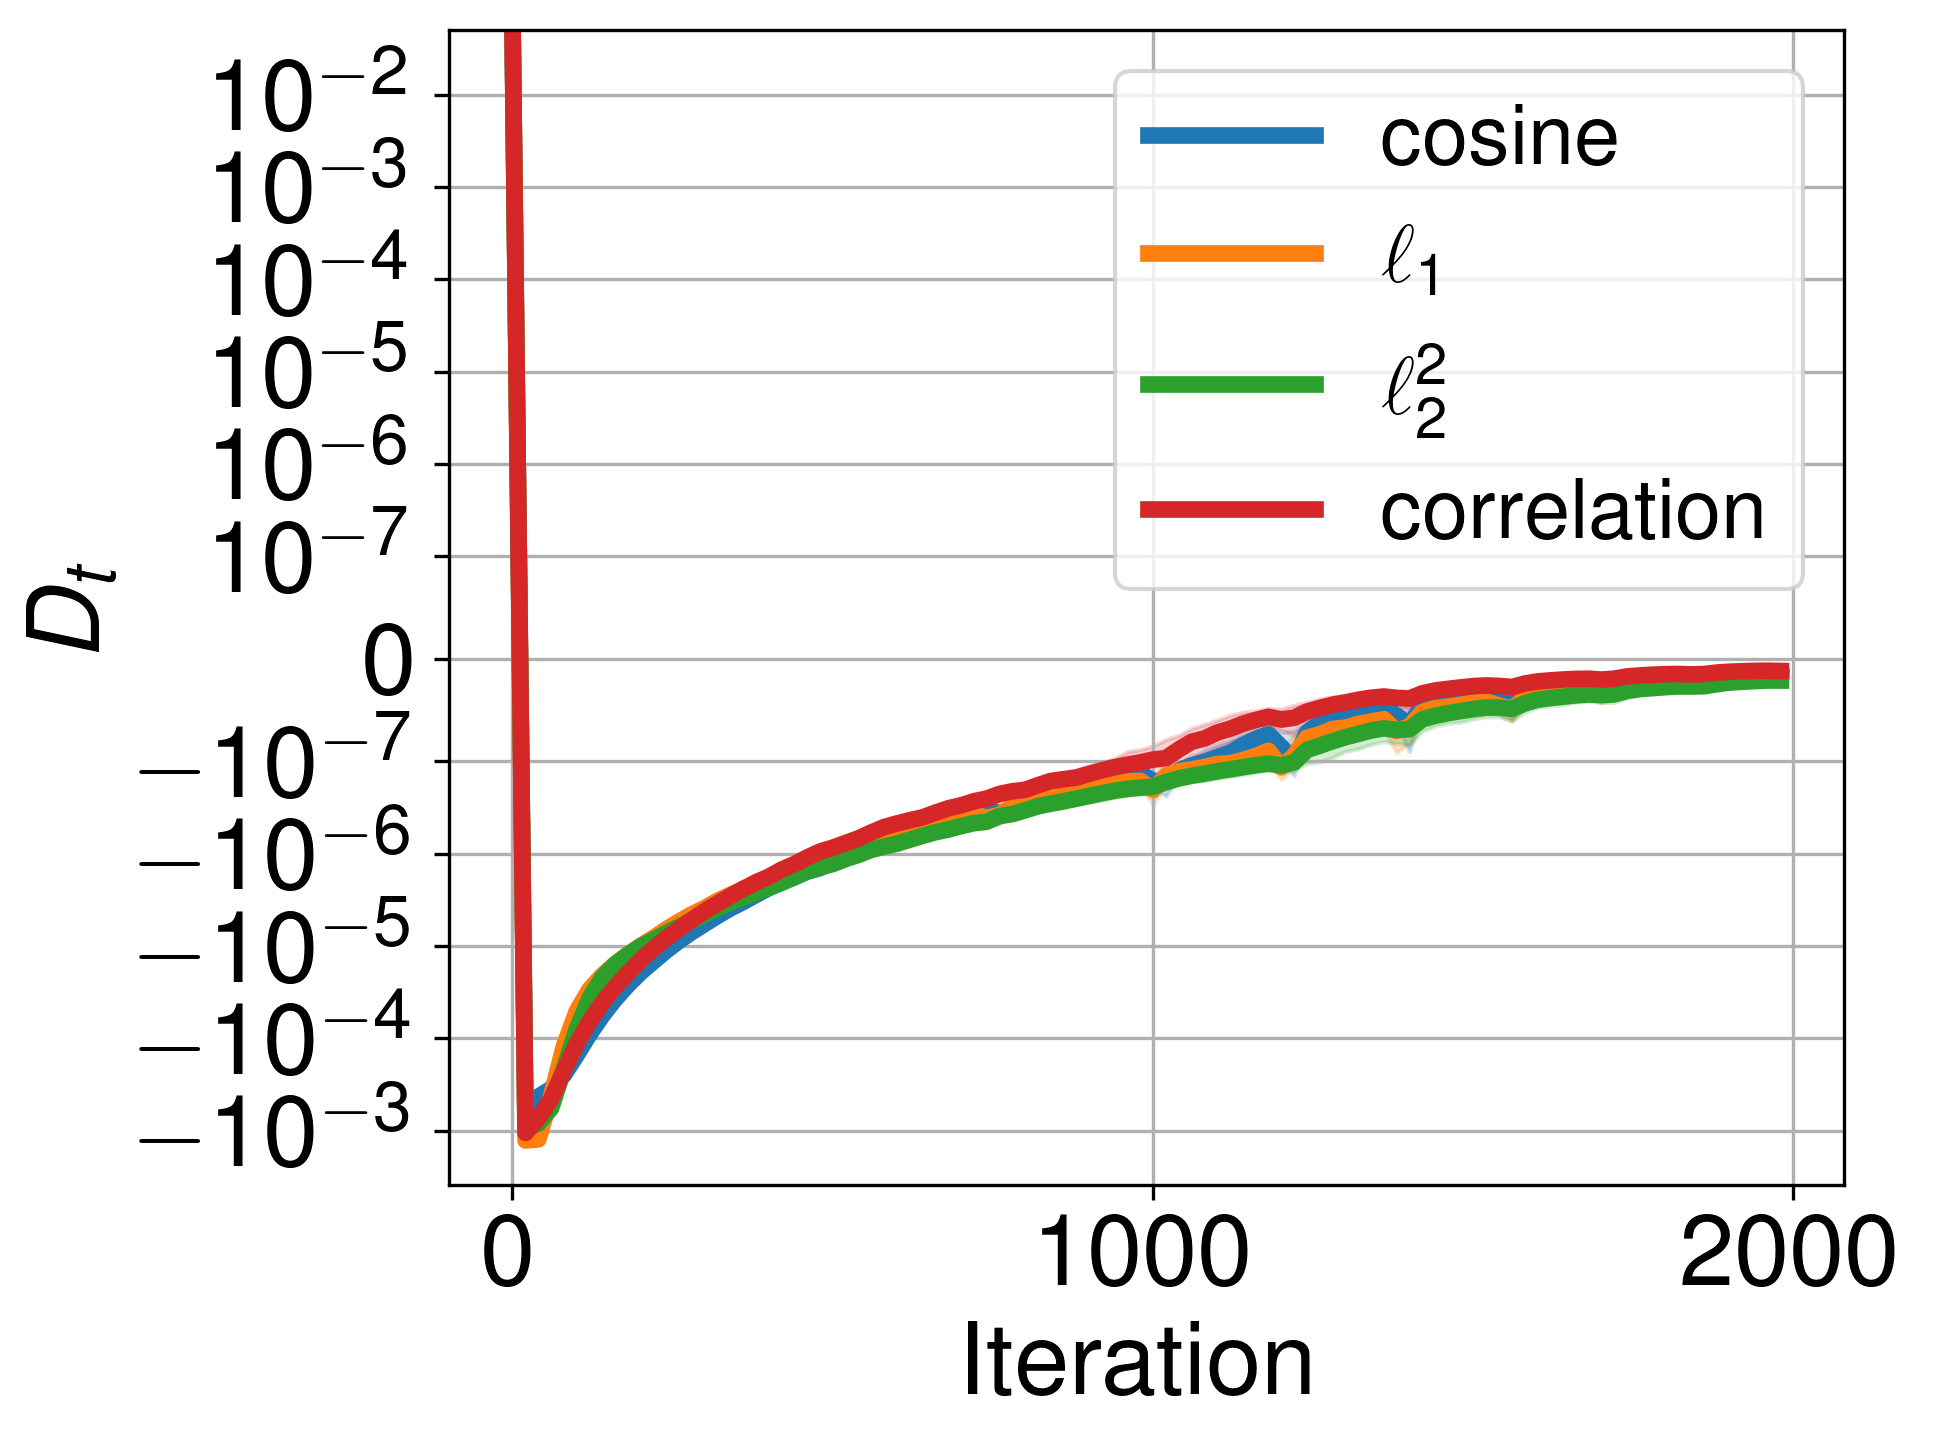

In [21]:
from glob import glob
import re
fig, ax = plt.subplots(figsize=(6,5))

df = pd.read_csv("../data_archive/fig_6_cellsim_summability_updated.csv")
df['$D_t$'] = df.groupby(['iteration', "metric", "filename"])['diff'].cumsum()
df["Metric"] = df['metric'].replace(
    {"l1": "$\ell_1$",
     "l2": "$\ell_2^2$"}
)

sns.lineplot(df.query("iteration < 2000"), ax=ax, x='iteration', y='$D_t$', hue="Metric", palette="tab10", linewidth=4)
ax.set_yscale('symlog', linthresh=0.0000001)
# ax.set_xscale('log')
ax.grid()
ax.set_xlabel("Iteration")
ax.legend(title=None, fontsize=20)
fig.savefig("../figures/fig_6_cellsim_summability.pdf", bbox_inches='tight')

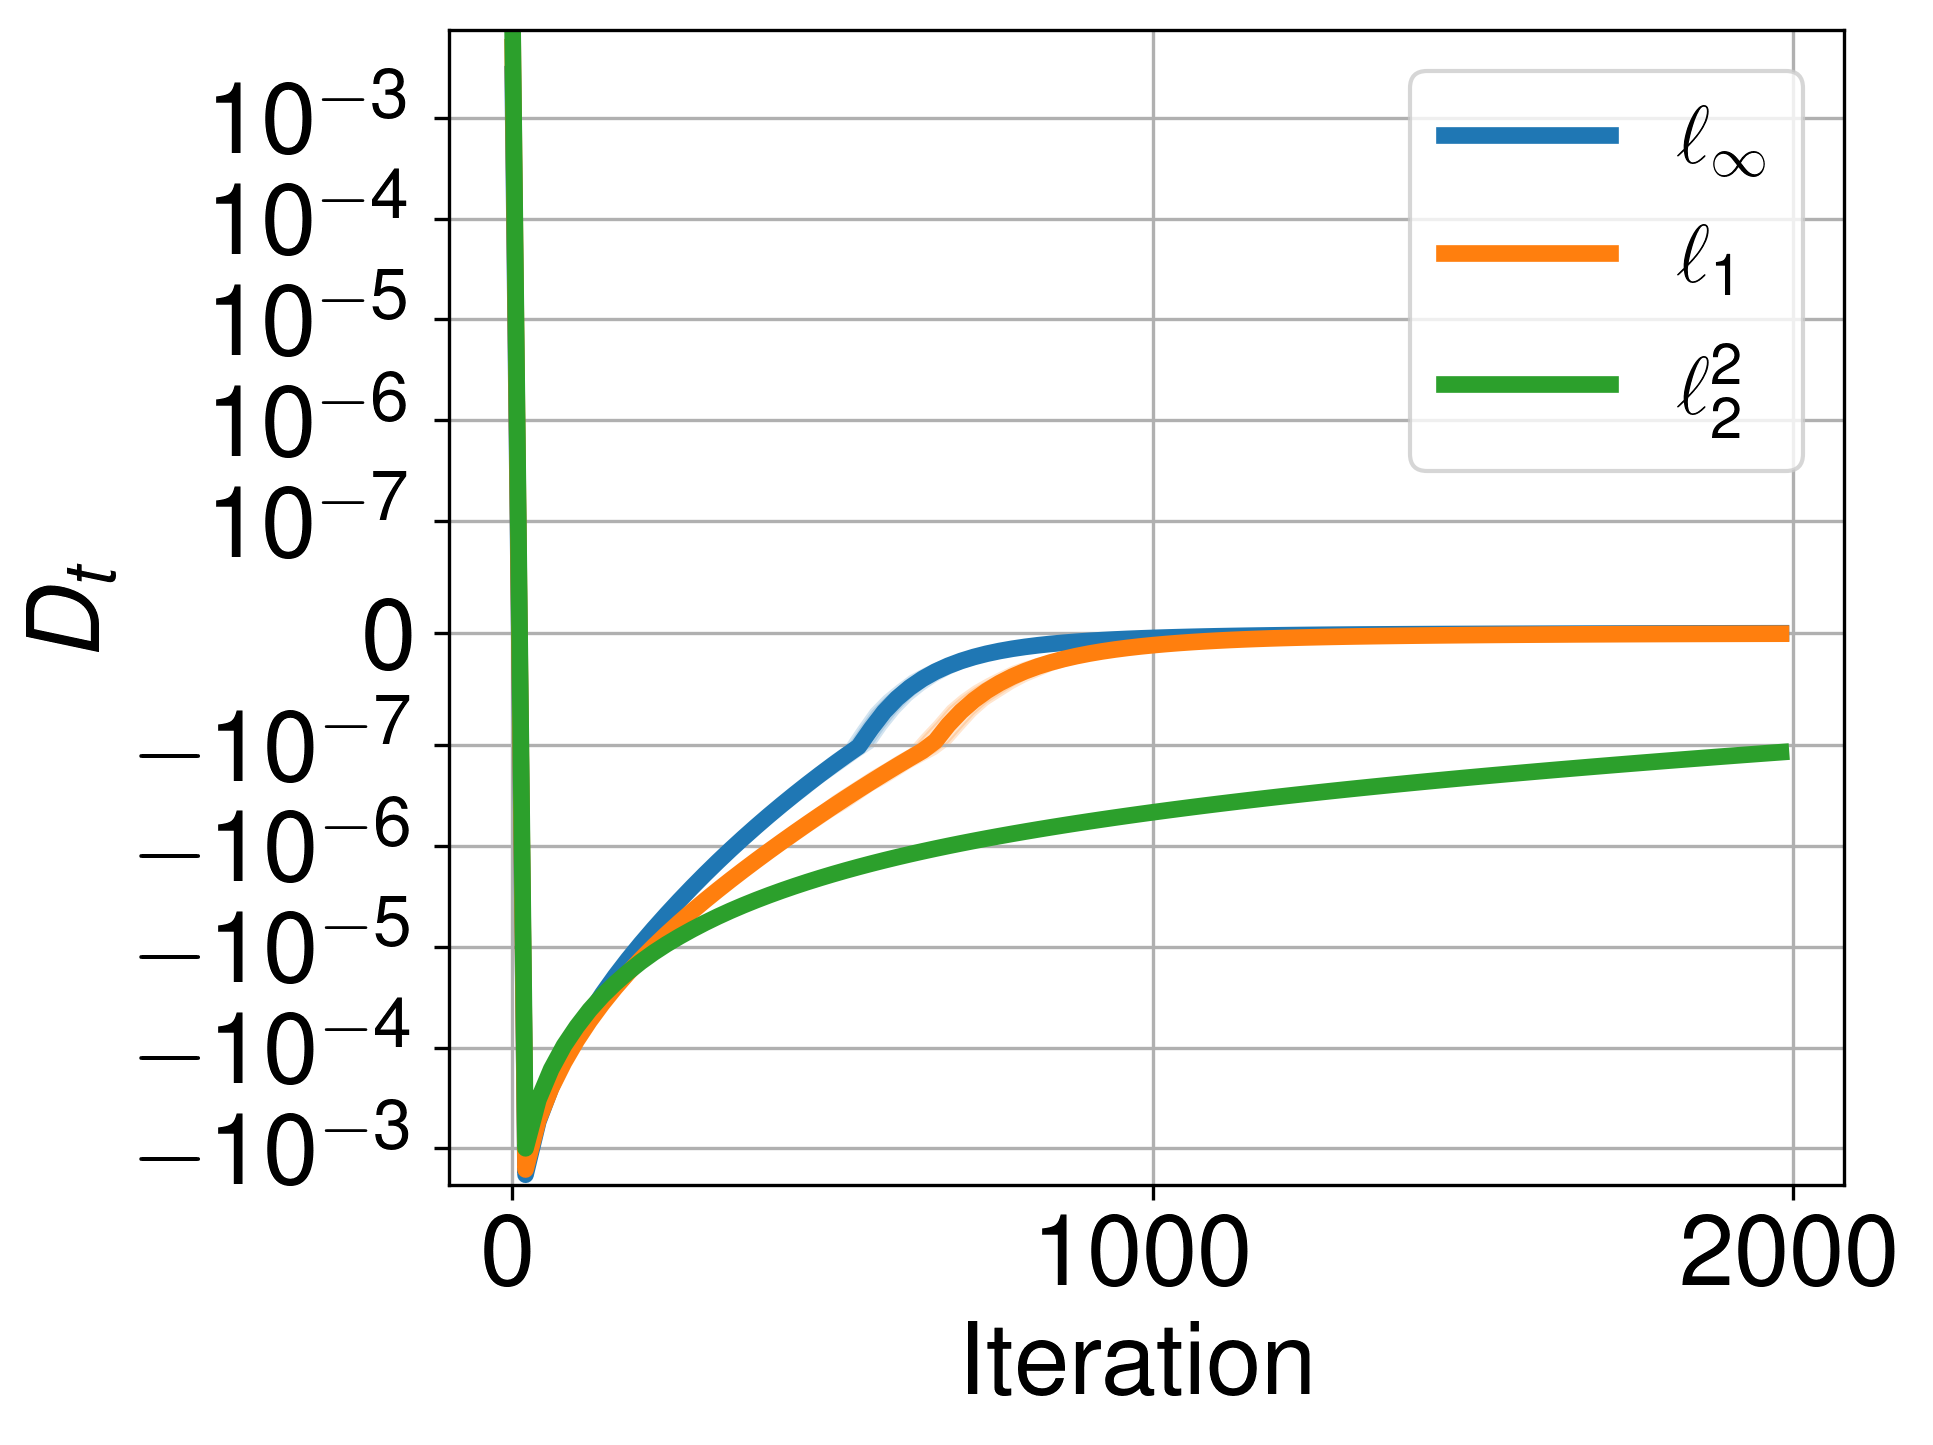

In [23]:
fig, ax = plt.subplots(figsize=(6,5))

df = pd.read_csv("../data_archive/fig_6_dotmark_summability_updated.csv")
df['Max'] = df.groupby(['iteration', "p"])['diff'].transform("max")
df['$D_t$'] = df.groupby(['iteration', "p", "filename"])['diff'].cumsum()
df["$p$"] = df['p'].replace(
    {1.0: "$\ell_1$",
     2.0: "$\ell_2^2$",
     np.inf: "$\ell_\infty$",}
)

sns.lineplot(df.query("iteration < 2000"), ax=ax, x='iteration', y='$D_t$', hue="$p$", palette="tab10", linewidth=4)
ax.set_yscale('symlog', linthresh=0.0000001)
# ax.set_xscale('log')
ax.grid()
ax.set_xlabel("Iteration")
ax.legend(title=None, fontsize=20)
fig.savefig("../figures/dotmark_summability.pdf", bbox_inches='tight')